In [255]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import sqlite3

In [ ]:
#Tạo một database
# 1. Kết nối đến database (nếu chưa có nó sẽ tự tạo file)
conn = sqlite3.connect('datathon_2026.db')

# 2. Danh sách các file CSV trong thư mục hiện tại
# Nếu các file nằm trong thư mục con, ông hãy thay đổi đường dẫn '.'
files = [f for f in os.listdir('.') if f.endswith('.csv')]

print(f"Tìm thấy {len(files)} file CSV. Đang bắt đầu import...")

# 3. Vòng lặp để đọc và ghi vào Database
for file in files:
    # Lấy tên file làm tên bảng (bỏ đuôi .csv)
    table_name = os.path.splitext(file)[0]
    
    try:
        # Đọc file CSV
        df = pd.read_csv(file)
        
        # Đẩy vào SQL
        # if_exists='replace' sẽ ghi đè nếu bảng đã tồn tại
        # index=False để không tạo thêm cột chỉ số của pandas vào SQL
        df.to_sql(table_name, conn, if_exists='replace', index=False)
        
        print(f"✅ Đã import thành công bảng: {table_name}")
    except Exception as e:
        print(f"❌ Lỗi khi import file {file}: {e}")

# 4. Đóng kết nối
print("-" * 30)
print("Hoàn tất! Tất cả 15 file đã nằm trong datathon_2026.db")

Tìm thấy 14 file CSV. Đang bắt đầu import...
✅ Đã import thành công bảng: customers
✅ Đã import thành công bảng: geography
✅ Đã import thành công bảng: inventory
✅ Đã import thành công bảng: orders


C:\Users\admin\AppData\Local\Temp\ipykernel_36584\295201842.py:17: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


✅ Đã import thành công bảng: order_items
✅ Đã import thành công bảng: payments
✅ Đã import thành công bảng: products
✅ Đã import thành công bảng: promotions
✅ Đã import thành công bảng: returns
✅ Đã import thành công bảng: reviews
✅ Đã import thành công bảng: sales
✅ Đã import thành công bảng: sample_submission
✅ Đã import thành công bảng: shipments
✅ Đã import thành công bảng: web_traffic
------------------------------
Hoàn tất! Tất cả 15 file đã nằm trong datathon_2026.db


In [257]:
cursor = conn.cursor()

1. Đọc và xử lý dữ liệu

In [258]:
customers=pd.read_csv("customers.csv")
geography=pd.read_csv("geography.csv")
inventory=pd.read_csv("inventory.csv")
order_items=pd.read_csv("order_items.csv")
orders=pd.read_csv("orders.csv")
payments=pd.read_csv("payments.csv")
products=pd.read_csv("products.csv")
promotions=pd.read_csv("promotions.csv")
returns= pd.read_csv("returns.csv")
reviews=pd.read_csv("reviews.csv")
sales=pd.read_csv("sales.csv")
sample_submission=pd.read_csv('sample_submission.csv')
shipments=pd.read_csv('shipments.csv')
web_traffic=pd.read_csv('web_traffic.csv')

C:\Users\admin\AppData\Local\Temp\ipykernel_36584\2661362707.py:4: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items=pd.read_csv("order_items.csv")


Xử lý dữ liệu và EDA

Khách hàng 

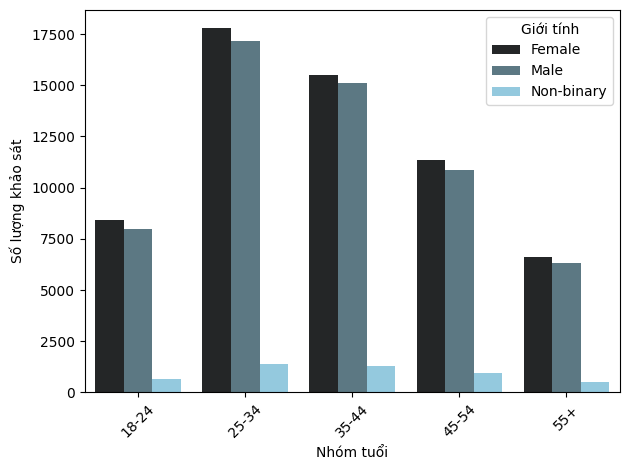

In [344]:
#Lập bảng gneder_age
query = """select gender, age_group, count(age_group) as count from customers group by gender, age_group """
gender_age=pd.read_sql(query, conn)
#Khởi tạo biểu đồ
plt.Figure(figsize=(10,6))
ax= sb.barplot(data= gender_age,x='age_group', y='count', hue='gender', palette='dark:skyblue')
plt.xlabel("Nhóm tuổi")
plt.ylabel("Số lượng khảo sát")
plt.legend(title= "Giới tính")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36584\4203081807.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2=sb.barplot(data=acquisition, x='acquisition_channel', y='count', palette='dark:yellow')


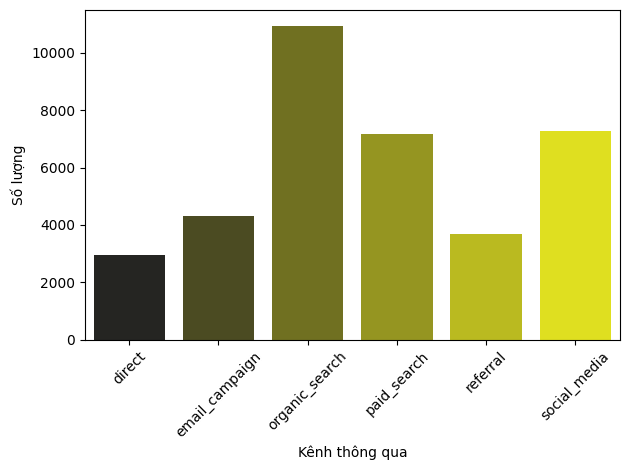

In [345]:
#Lập bảng acqusition_channel
query2= """select age_group, acquisition_channel, count(acquisition_channel) as count from customers where age_group = "25-34" group by age_group, acquisition_channel """
acquisition=pd.read_sql(query2,conn)
#Khởi tạo biểu đồ
ax2=sb.barplot(data=acquisition, x='acquisition_channel', y='count', palette='dark:yellow')
plt.xlabel("Kênh thông qua")
plt.ylabel("Số lượng")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [285]:
customers_geography=pd.merge(customers, geography, on="zip", how='inner')

In [286]:
region=customers_geography['region'].value_counts(normalize=True)
print(region)

region
East       0.477143
Central    0.363208
West       0.159649
Name: proportion, dtype: float64


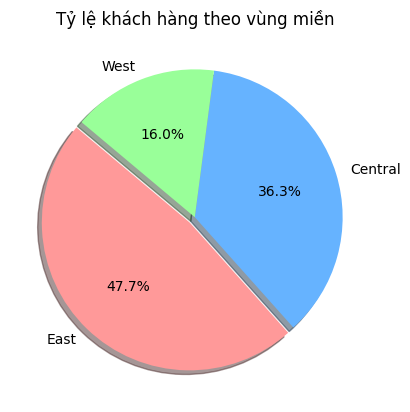

In [287]:
#Khởi tạo chart
labels = region.index
sizes = region.values
colors = ['#ff9999','#66b3ff','#99ff99']
plt.pie(
    sizes,
    labels=labels,
    colors = colors,
    autopct='%1.1f%%',
    startangle = 140,
    explode=(0.05,0,0),
    shadow=True
)
plt.title('Tỷ lệ khách hàng theo vùng miền')
plt.show()

Kết luận: Khách hàng đa phần là những người trong độ tuổi 25-34, hiện đang sinh sống tại miền Bắc và kênh truyền thông dùng đến chủ yếu là organic_search
=> Nhắm vào khách hàng 25-34 tuổi 

Phân tích chất lượng khách hàng 

Phân tích hành vi mua sắm 


In [288]:
#Xác định xu hướng mua của khách hàng theo từng phân khúc và loại sản phẩm 
query ="""select c.age_group, p.segment, count(o.customer_id) as count from customers c join orders o on c.customer_id = o.customer_id join order_items ot on o.order_id = ot.order_id 
join products p on ot.product_id = p.product_id where age_group="25-34" group by 1,2"""
don_tren_tung_khach_hang=pd.read_sql(query, conn)
don_tren_tung_khach_hang.head()

,age_group,segment,count
0,25-34,Activewear,67115
1,25-34,All-weather,6654
2,25-34,Balanced,30593
3,25-34,Everyday,54031
4,25-34,Performance,28545


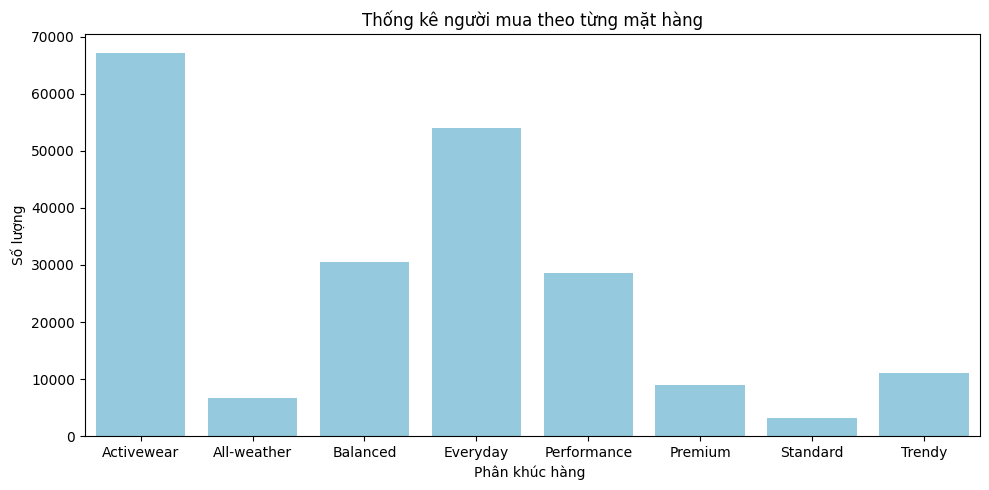

In [289]:
#Khởi tạo biểu đồ
plt.figure(figsize=(10,5))
ax=sb.barplot(data=don_tren_tung_khach_hang, x="segment", y="count", color="skyblue")
plt.title("Thống kê người mua theo từng mặt hàng")
plt.xlabel("Phân khúc hàng ")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()

In [ ]:
#Thống kê số lượng người sử dụng device tương ứng với từng kênh
query= """select c.acquisition_channel, o.device_type, count(c.acquisition_channel) as count from customers c join orders o on c.customer_id=o.customer_id group by 1,2"""
acquisition_device = pd.read_sql(query, conn)
acquisition_device.head()

,acquisition_channel,device_type,count
0,direct,desktop,20724
1,direct,mobile,23501
2,direct,tablet,7794
3,email_campaign,desktop,31140
4,email_campaign,mobile,35008


C:\Users\admin\AppData\Local\Temp\ipykernel_36584\297485058.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:skyblue'` for the same effect.

  ax = sb.barplot(data= acquisition_device, x="acquisition_channel", y="count", hue="device_type", color="skyblue")


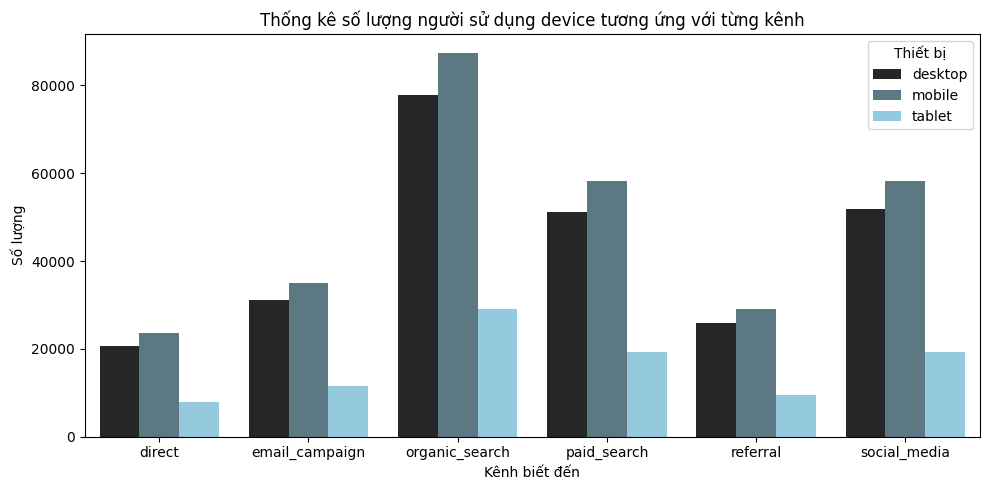

In [346]:
#Khởi tạo biểu đồ
plt.figure(figsize=(10,5))
ax = sb.barplot(data= acquisition_device, x="acquisition_channel", y="count", hue="device_type", color="skyblue")
plt.title("Thống kê số lượng người sử dụng device tương ứng với từng kênh")
plt.xlabel("Kênh biết đến")
plt.ylabel("Số lượng")
plt.legend(title="Thiết bị")
plt.tight_layout()
plt.show()

In [ ]:
#Tách brand name với code sản phẩm 
products[['brand', 'code']]= products['product_name'].str.split(' ', n=1, expand=True)
products.head()

,product_id,product_name,category,segment,size,color,price,cogs,average_price_margin,brand,code
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,11058.772500,SaigonFlex,UC-01
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,9522.509613,SaigonFlex,UC-02
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278,15950.920258,SaigonFlex,UC-03
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954,15753.173099,SaigonFlex,UC-04
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406,15765.442536,SaigonFlex,UC-05


In [347]:
#Xác định các đơn hàng đã được delivered
orders_filtered = orders[orders['order_status'] == 'delivered']
#Thống kê doanh thu thông qua các đơn đã được delivered của từng brand
order_payment = payments.groupby('order_id')['payment_value'].sum().reset_index()
brand_purchase = pd.merge(
    order_items[['product_id', 'order_id']],
    order_payment,
    on='order_id',
    how='left'
).merge(
    orders_filtered, on='order_id', how='left'
).merge(
    products[['product_id', 'brand']],
    on='product_id',
    how='left'
)
brand_purchase = brand_purchase.groupby(['brand', 'order_id'])['payment_value'].first().reset_index()

brand_purchase = brand_purchase.groupby('brand')['payment_value'].mean().reset_index(name='doanh_thu_trung_binh')
brand_purchase

,brand,doanh_thu_trung_binh
0,BambooCraft,45046.563258
1,DragonWear,37222.522838
2,HanoiStreet,16994.890950
3,IndigoViet,53257.970160
4,LotusWear,34978.268312
5,MekongFit,17462.309873
6,MekongStyle,53177.460774
7,NamStyle,6788.724110
8,PhoenixWear,25168.294284
9,SaigonCore,14736.194306


C:\Users\admin\AppData\Local\Temp\ipykernel_36584\1121150059.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sb.barplot(x='brand', y='doanh_thu_trung_binh', data=brand_purchase, palette='viridis')


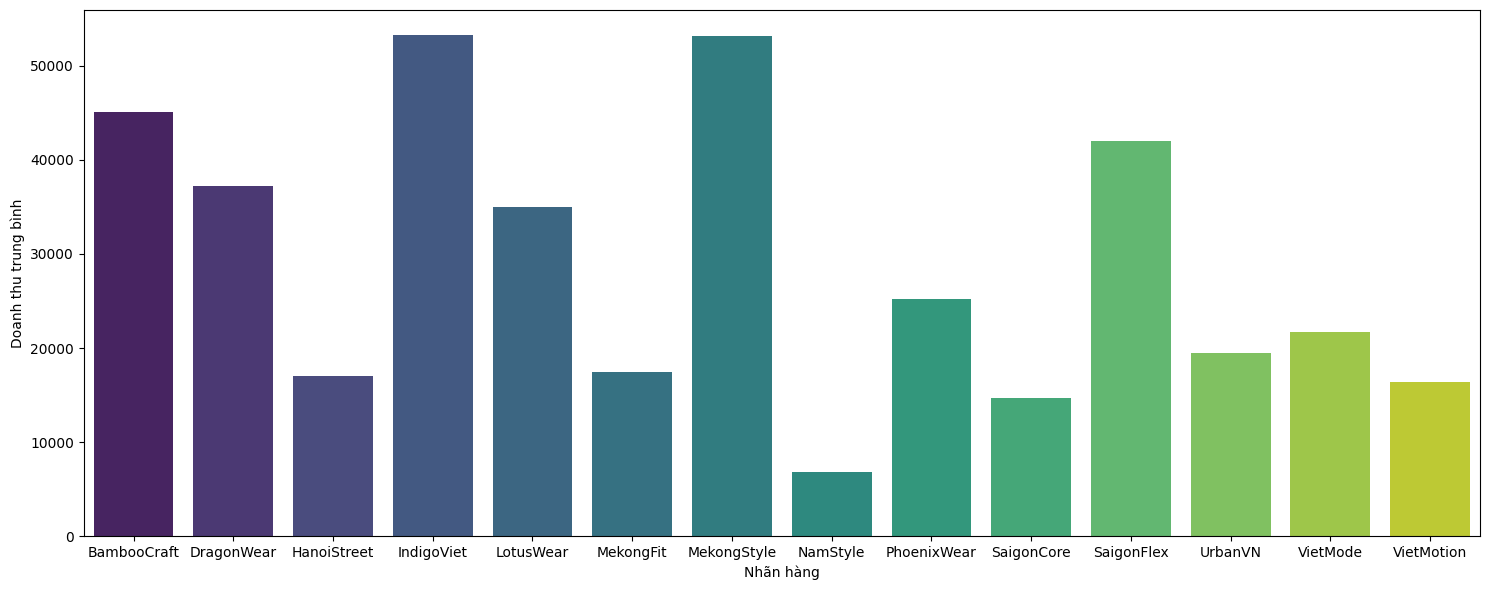

In [294]:
plt.figure(figsize=(15,6))
ax= sb.barplot(x='brand', y='doanh_thu_trung_binh', data=brand_purchase, palette='viridis')
plt.xlabel('Nhãn hàng')
plt.ylabel('Doanh thu trung bình')
plt.tight_layout()
plt.show()

In [ ]:
#Xác định doanh thu của từng kênh
order_payment = payments.groupby('order_id')['payment_value'].sum().reset_index()
acquisition_pay = orders_filtered[['customer_id', 'order_id']] \
    .merge(order_payment, on='order_id', how='left') \
    .merge(customers[['customer_id', 'acquisition_channel']], on='customer_id', how='left')
acquisition_pay = acquisition_pay.groupby('acquisition_channel')['payment_value'] \
    .sum().reset_index(name='total_revenue')
acquisition_pay.head()

,acquisition_channel,total_revenue
0,direct,9.684665e+08
1,email_campaign,1.442798e+09
2,organic_search,3.635719e+09
3,paid_search,2.402946e+09
4,referral,1.203593e+09


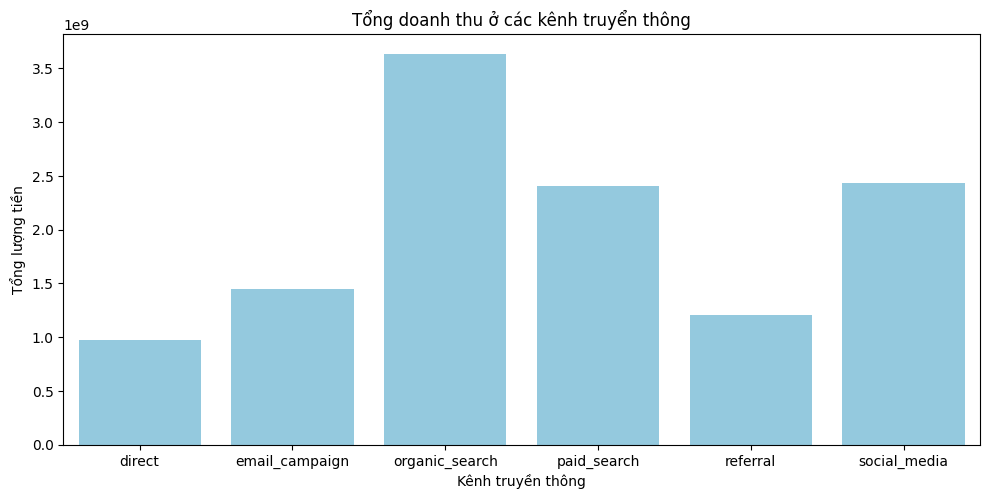

In [ ]:
#Khởi tạo biểu đồ
plt.figure(figsize=(10,5))
ax= sb.barplot(data=acquisition_pay, x='acquisition_channel', y='total_revenue', color="skyblue")
plt.xlabel('Kênh truyền thông')
plt.ylabel('Tổng lượng tiền')
plt.tight_layout()
plt.title("Tổng doanh thu ở các kênh truyển thông")
plt.show()

In [348]:
#Xác định doanh thu từng nơi
geography_value = pd.merge(customers[['customer_id','zip']], geography[['zip','region']], on="zip", how= "left")\
                    .merge(orders_filtered[['customer_id', 'order_id']], on='customer_id', how='inner')\
                    .merge(payments[['order_id', 'payment_value']], on='order_id', how='inner')
geography_value= geography_value.groupby(['region'])['payment_value'].sum().dropna().reset_index(name='revenue')
geography_value.head()

,region,revenue
0,Central,3.579163e+09
1,East,5.636229e+09
2,West,2.874185e+09


C:\Users\admin\AppData\Local\Temp\ipykernel_36584\622775065.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sb.barplot(data=geography_value, x='region', y='revenue', palette="dark:skyblue")


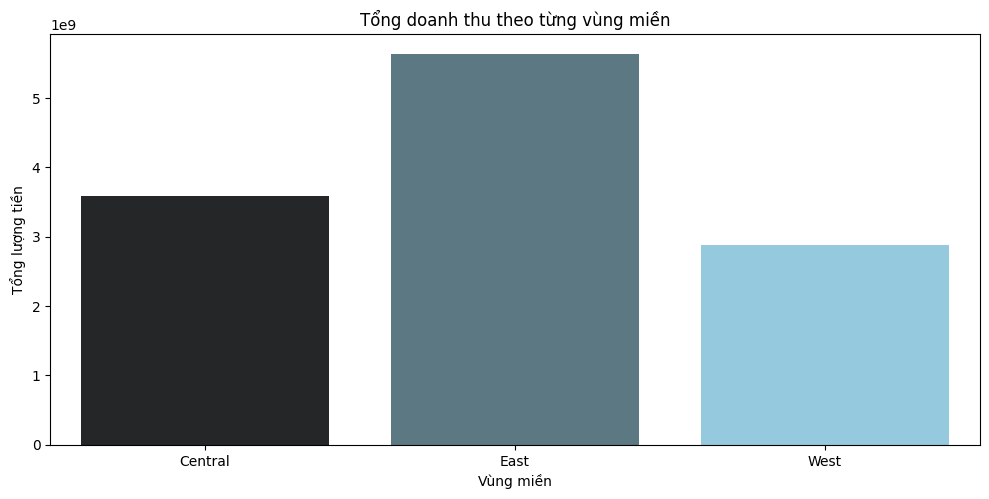

In [349]:
plt.figure(figsize=(10,5))
ax= sb.barplot(data=geography_value, x='region', y='revenue', palette="dark:skyblue")
plt.xlabel('Vùng miền')
plt.ylabel('Tổng lượng tiền')
plt.tight_layout()
plt.title("Tổng doanh thu theo từng vùng miền")
plt.show()

=> Đa phần khách hàng trong khảo sát đều là người đi làm, chủ yếu là ở phía Bắc với độ tuổi chủ yếu khoảng từ 25 đến trên 55 tuổi. Phần nhiều biết đến từ organic search, social media và paid_search

Phân tích sản phẩm 

In [299]:
#Tính tỷ suất lợi nhuận trên mỗi đơn hàng theo segment
query= """select segment, avg((price-cogs)/price) as average_profit_margin from products group by segment"""
average_segment= pd.read_sql_query(query, conn)
average_segment.head(8)

,segment,average_profit_margin
0,Activewear,0.265600
1,All-weather,0.284176
2,Balanced,0.258038
3,Everyday,0.236343
4,Performance,0.263650
5,Premium,0.285377
6,Standard,0.313442
7,Trendy,0.240758


In [300]:
#Tính điểm trung bình đánh giá trên các loại mặt hàng
query= """select p.segment, avg(r.rating) as average_rating from products p join reviews r on p.product_id = r.product_id group by segment"""
average_rate= pd.read_sql_query(query, conn)
average_rate.head()

,segment,average_rating
0,Activewear,3.929863
1,All-weather,3.927487
2,Balanced,3.933057
3,Everyday,3.944827
4,Performance,3.937205


C:\Users\admin\AppData\Local\Temp\ipykernel_36584\1835073488.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='segment', y='average_profit_margin', data=segment_chart, ax=ax1, palette='Blues_r')


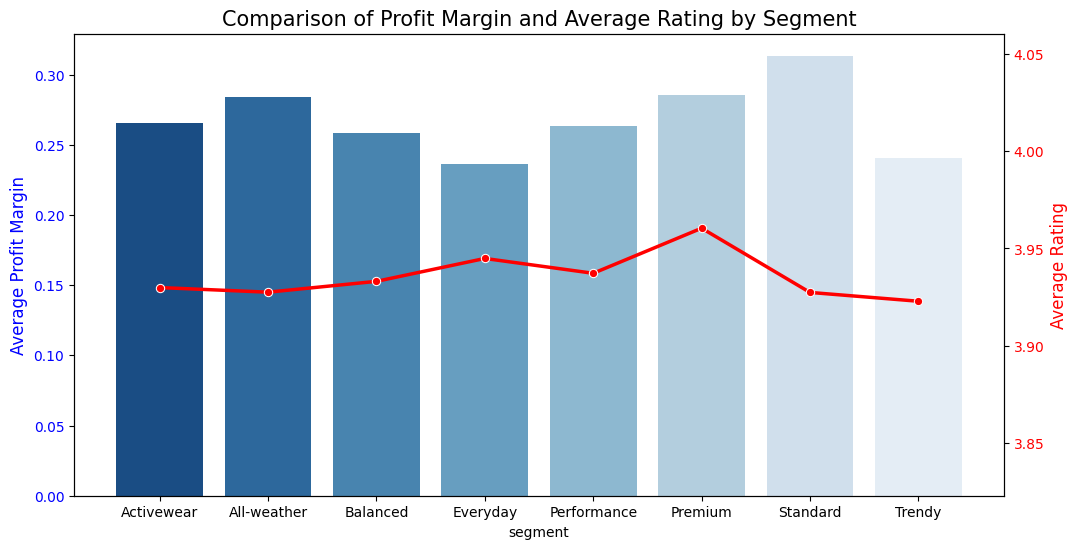

In [301]:
#Khởi tạo biểu đồ
#Gộp hai bảng 
segment_chart = pd.merge(average_segment, average_rate, on="segment", how="inner")
fig, ax1 = plt.subplots(figsize=(12,6))
#Vẽ bar chart cho trục average profit margin
sb.barplot(x='segment', y='average_profit_margin', data=segment_chart, ax=ax1, palette='Blues_r')
ax1.set_ylabel('Average Profit Margin', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Comparison of Profit Margin and Average Rating by Segment', fontsize=15)

# 3. Tạo trục Y thứ hai cho Average Rating
ax2 = ax1.twinx()

# 4. Vẽ Line Chart cho Average Rating (Trục Y bên phải)
sb.lineplot(x='segment', y='average_rating', data=segment_chart, ax=ax2, color='red', marker='o', linewidth=2.5)
ax2.set_ylabel('Average Rating', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Giới hạn trục Y cho Rating để thấy rõ sự biến động (tùy chọn)
ax2.set_ylim(segment_chart['average_rating'].min() - 0.1, segment_chart['average_rating'].max() + 0.1)

plt.show()

In [350]:
#Xác định lý do trả hàng theo số lượng đơn bị trả
query="""select return_reason, sum(return_quantity) as total_quantity_return from returns group by 1"""
reason=pd.read_sql(query, conn)
reason.head(
    
)


,return_reason,total_quantity_return
0,changed_mind,19144
1,defective,22274
2,late_delivery,10768
3,not_as_described,19358
4,wrong_size,38042


C:\Users\admin\AppData\Local\Temp\ipykernel_36584\735779192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=reason, y="total_quantity_return", x='return_reason', palette='viridis')


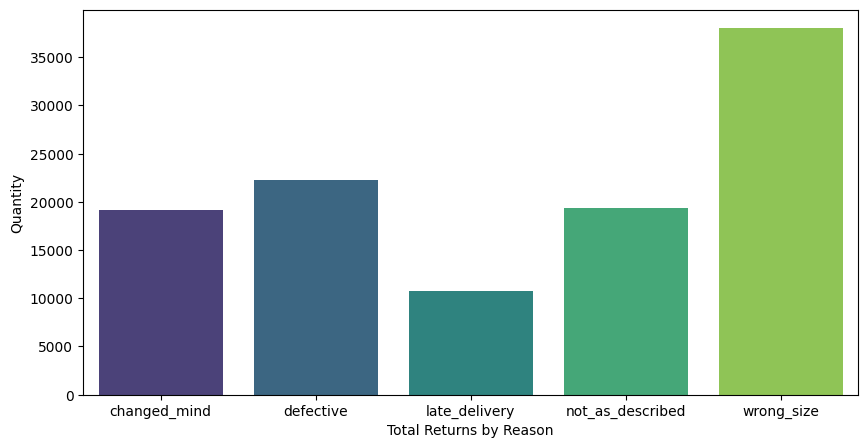

In [351]:
plt.figure(figsize=(10,5))
sb.barplot(data=reason, y="total_quantity_return", x='return_reason', palette='viridis')
plt.xlabel("Total Returns by Reason")
plt.ylabel("Quantity")
plt.show()

Wrong size là lí do bị trả nhiều nhất => Xác định size bị trả nhiều nhất ?

In [ ]:
#Xác định tổng số tiền phải trả theo từng size
orders_returned = orders[orders['order_status'] == 'returned']
orders_returned_size = pd.merge(orders_returned[['order_id']], order_items[['order_id', 'product_id']], on='order_id', how='left') \
                        .merge(products[['product_id', 'size']], on='product_id', how='left')\
                            .merge(returns[['order_id', 'refund_amount']], on='order_id', how='inner')
orders_returned_size= orders_returned_size.groupby('size')['refund_amount'].sum().reset_index(name="Tổng tiền phải hoàn trả")
orders_returned_size

,size,Tổng tiền phải hoàn trả
0,L,1.270458e+08
1,M,1.218922e+08
2,S,1.232573e+08
3,XL,1.665825e+08


C:\Users\admin\AppData\Local\Temp\ipykernel_36584\1099604646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=orders_returned_size, y="Tổng tiền phải hoàn trả", x='size', palette='viridis')


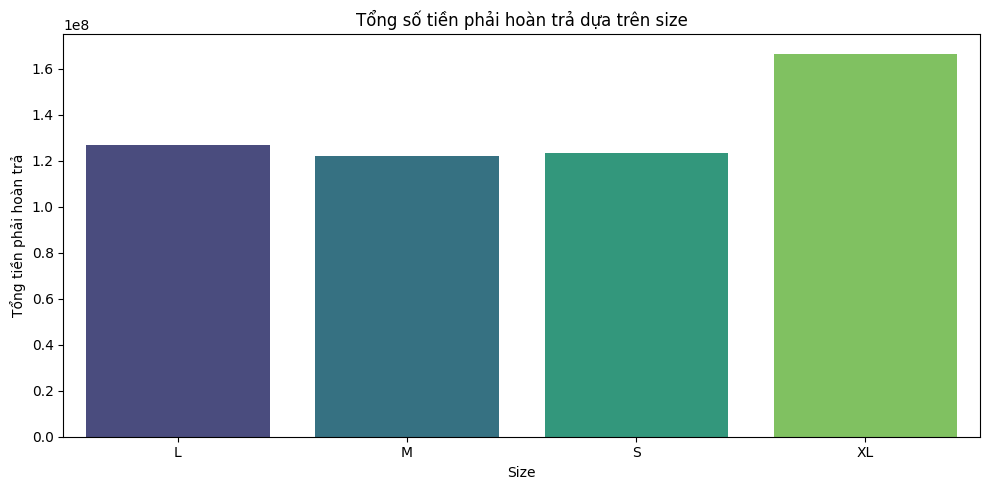

In [352]:
plt.figure(figsize=(10,5))
sb.barplot(data=orders_returned_size, y="Tổng tiền phải hoàn trả", x='size', palette='viridis')
plt.ylabel("Tổng tiền phải hoàn trả")
plt.xlabel("Size")
plt.title("Tổng số tiền phải hoàn trả dựa trên size")
plt.tight_layout()
plt.show()

Promotions

In [307]:
# Tạo cột phân loại số lượng promo
order_items['promo_count'] = order_items[['promo_id', 'promo_id_2']].notnull().sum(axis=1)

# Nối với bảng payments để lấy giá trị thanh toán
df_promo = order_items.merge(payments, on='order_id', how='left')

# Thống kê nhanh
promo_stats = df_promo.groupby('promo_count').agg({
    'payment_value': 'mean',
    'quantity': 'mean'
}).reset_index()


In [ ]:
#Gộp với bảng products tạo revenue_discount(doanh thu thực)
revenue_discount = order_items.merge(products[['product_id', 'cogs']], on='product_id', how='left')

#Tính Revenue và Profit cho từng dòng sản phẩm
# Doanh thu thực tế = (Số lượng * Đơn giá) - Tiền giảm giá
revenue_discount['net_revenue'] = (revenue_discount['quantity'] * revenue_discount['unit_price']) - revenue_discount['discount_amount']

# Lợi nhuận = Doanh thu thực tế - (Số lượng * Giá vốn)
revenue_discount['profit'] = revenue_discount['net_revenue'] - (revenue_discount['quantity'] * revenue_discount['cogs'])

# Biên lợi nhuận (%)
revenue_discount['margin_pct'] = (revenue_discount['profit'] / revenue_discount['net_revenue']) * 100
revenue_discount

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,promo_count,cogs,net_revenue,profit,margin_pct
0,1,2400,7,1138.22,0.0,NaN,NaN,0,1053.798008,7967.54,590.953941,7.417019
1,2,609,7,10166.25,0.0,NaN,NaN,0,8987.704231,71163.75,8249.820384,11.592729
2,3,396,3,11220.33,0.0,NaN,NaN,0,10091.012256,33660.99,3387.953233,10.064925
3,4,635,5,10639.25,0.0,NaN,NaN,0,9205.430478,53196.25,7169.097610,13.476697
4,6,1935,1,1597.84,0.0,NaN,NaN,0,1048.696357,1597.84,549.143643,34.367874
...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,690,8,4473.92,0.0,NaN,NaN,0,3100.062695,35791.36,10990.858436,30.708133
714665,834377,1995,7,5250.79,0.0,NaN,NaN,0,3025.421056,36755.53,15577.582610,42.381602
714666,834387,2331,8,7389.06,0.0,NaN,NaN,0,6671.816431,59112.48,5737.948549,9.706831
714667,834392,1115,5,4767.33,0.0,NaN,NaN,0,4587.478861,23836.65,899.255696,3.772576


In [ ]:
#Tính trung vị theo từng đơn khuyến mãi
stacking_analysis = revenue_discount.groupby('promo_count').agg({
    'quantity': 'mean',
    'net_revenue': 'mean',
    'profit': 'mean',
    'margin_pct': 'mean'
}).reset_index()

stacking_analysis

,promo_count,quantity,net_revenue,profit,margin_pct
0,0,4.496613,25082.613905,5007.414996,20.832516
1,1,4.495324,16950.378195,-2454.504526,-14.737822
2,2,4.053398,27481.985437,566.045943,1.405858


In [ ]:
# Chia mức giảm giá thành các nhóm (ví dụ: 0%, 0-10%, 10-20%, >20%)
bins=[-1, 0, 10, 20, 100]
labels=['No Discount', '0-10%', '10-20%', '>20%']


In [ ]:

# Tính % discount trước: (discount_amount / (quantity * unit_price))
order_items['discount_pct'] = (order_items['discount_amount'] / (order_items['unit_price'])) * 100

order_items['discount_range'] = pd.cut(order_items['discount_pct'], bins=bins, labels=labels)

# Tính tỷ lệ trả hàng theo mức giảm giá
order_by_promo = order_items.groupby('discount_range').agg({
    'order_id':'nunique',
    'quantity':'sum'
}).reset_index()
order_by_promo

,discount_range,order_id,quantity
0,No Discount,398972,1971104
1,0-10%,19090,66261
2,10-20%,32362,58478
3,>20%,161287,763431


C:\Users\admin\AppData\Local\Temp\ipykernel_36584\178073016.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1=sb.barplot(data= order_by_promo,x='discount_range', y='quantity', palette='viridis')


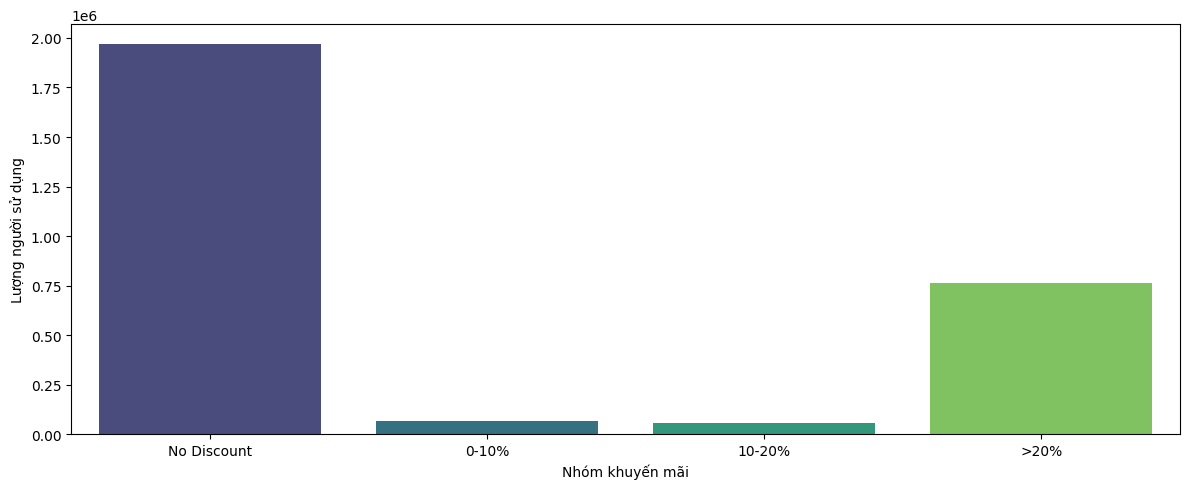

In [312]:
plt.figure(figsize=(12,5))
ax1=sb.barplot(data= order_by_promo,x='discount_range', y='quantity', palette='viridis')
plt.xlabel('Nhóm khuyến mãi')
ax1.set_ylabel('Lượng người sử dụng')
plt.tight_layout()
plt.show()

Xác định các đơn bị trả theo từng promotions

In [313]:
# Nối với bảng returns để đánh dấu đơn bị trả
df_returns = revenue_discount.merge(returns[['order_id', 'product_id', 'return_id']], on=['order_id', 'product_id'], how='left')

df_returns['is_returned'] = df_returns['return_id'].notnull().astype(int)

# Chia mức giảm giá thành các nhóm (ví dụ: 0%, 0-10%, 10-20%, >20%)
# Bạn cần tính % discount trước: (discount_amount / (quantity * unit_price))
df_returns['discount_pct'] = (df_returns['discount_amount'] / (df_returns['quantity'] * df_returns['unit_price'])) * 100

df_returns['discount_range'] = pd.cut(df_returns['discount_pct'], bins=bins, labels=labels)

# Tính tỷ lệ trả hàng theo mức giảm giá
return_by_promo = df_returns.groupby('discount_range')['is_returned'].mean().reset_index(name='returned')
return_by_promo['returned']= return_by_promo['returned']*100
return_by_promo

,discount_range,returned
0,No Discount,5.590218
1,0-10%,5.693415
2,10-20%,5.581038
3,>20%,5.440154


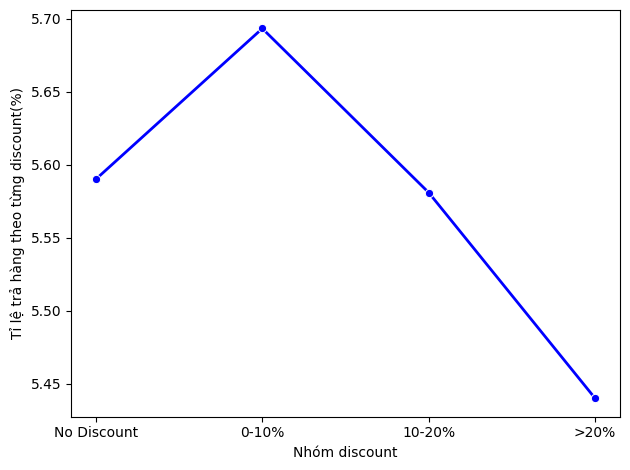

In [314]:
plt.Figure(figsize=(10,5))
ax2=sb.lineplot(data=return_by_promo,x='discount_range', y='returned', color='blue', marker='o', linewidth=2)
plt.xlabel('Nhóm discount')
plt.ylabel('Tỉ lệ trả hàng theo từng discount(%)')
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36584\1083694726.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1=sb.barplot(data= stacking_analysis,x='promo_count', y='net_revenue', palette='viridis')


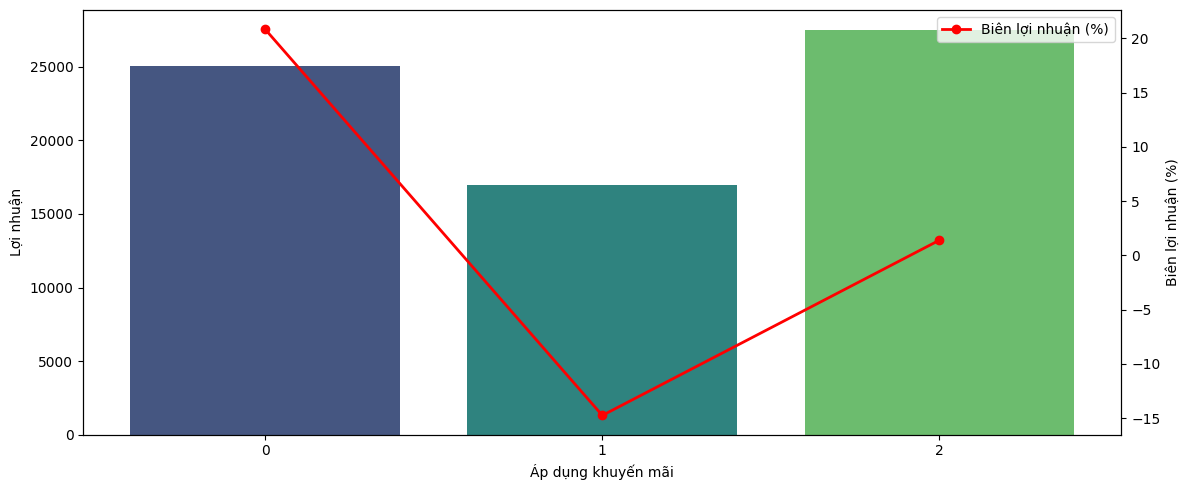

In [315]:
plt.figure(figsize=(12,5))
ax1=sb.barplot(data= stacking_analysis,x='promo_count', y='net_revenue', palette='viridis')
plt.xlabel('Áp dụng khuyến mãi')
ax1.set_ylabel('Lợi nhuận')
ax2 = ax1.twinx()
lns = ax2.plot(stacking_analysis['promo_count'], stacking_analysis['margin_pct'], 
               color='red', marker='o', linewidth=2, label='Biên lợi nhuận (%)')
ax2.legend(loc='upper right')
ax2.set_ylabel('Biên lợi nhuận (%)')
plt.tight_layout()
plt.show()


In [316]:
web_traffic.head()

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral


Lưu lượng truy cập

In [317]:
#Chỉnh sửa data cột date
web_traffic['date']=pd.to_datetime(web_traffic['date'])
#Lọc năm 
web_traffic['year']=web_traffic['date'].dt.year
#Lọc theo year
year_access= web_traffic.groupby(['year', 'traffic_source'])['page_views'].sum().reset_index()
year_access.head()

,year,traffic_source,page_views
0,2013,direct,2526241
1,2013,email_campaign,2674029
2,2013,organic_search,9408910
3,2013,paid_search,6237302
4,2013,referral,2406763


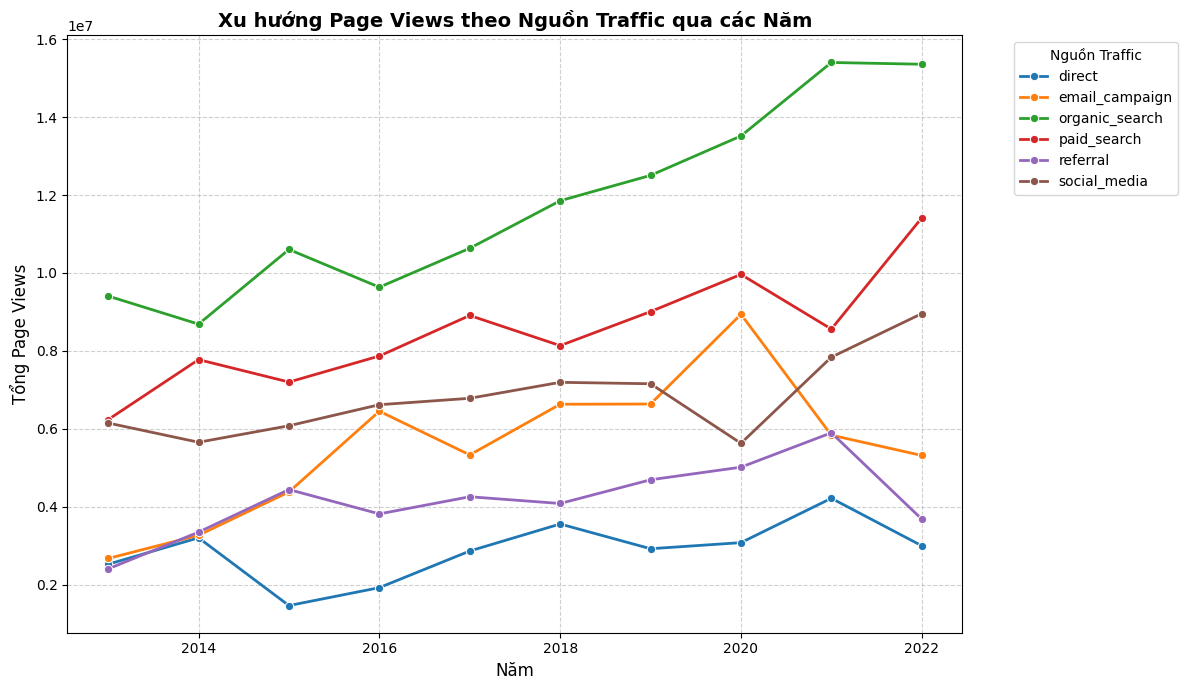

In [ ]:
#Khởi tạo biểu đồ
plt.figure(figsize=(12, 7))

# Vẽ biểu đồ đường
sb.lineplot(data=year_access, x='year', y='page_views', hue='traffic_source', marker='o', linewidth=2)

# Tùy chỉnh biểu đồ để chuyên nghiệp hơn cho bài thi Datathon 
plt.title('Xu hướng Page Views theo Nguồn Traffic qua các Năm', fontsize=14, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Tổng Page Views', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Nguồn Traffic', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [319]:
#Chỉnh sửa cột order-date bên trong orders
orders['order_date']=pd.to_datetime(orders['order_date'])
#Đặt năm 2022 làm chuẩn ở cả hai bảng orders và web_traffic
orders_2022= orders[orders['order_date'].dt.year==2022]
web_traffic_2022= web_traffic[web_traffic['date'].dt.year==2022]
#Xác định tháng trong năm 2022
web_traffic_2022['month'] = web_traffic_2022['date'].dt.month
orders_2022['month'] = orders_2022['order_date'].dt.month

# Nhóm theo tháng
monthly_traffic = web_traffic_2022.groupby('month')['page_views'].sum().reset_index()
monthly_orders = orders_2022.groupby('month')['order_id'].nunique().reset_index()

# Kết hợp hai bảng
analysis_2022 = monthly_traffic.merge(monthly_orders, on='month')
analysis_2022.columns = ['month', 'page_views', 'order_count']

analysis_2022.head()

,month,page_views,order_count
0,1,2322247,1672
1,2,2873816,2106
2,3,4422852,4068
3,4,5656622,4335
4,5,5533820,3929


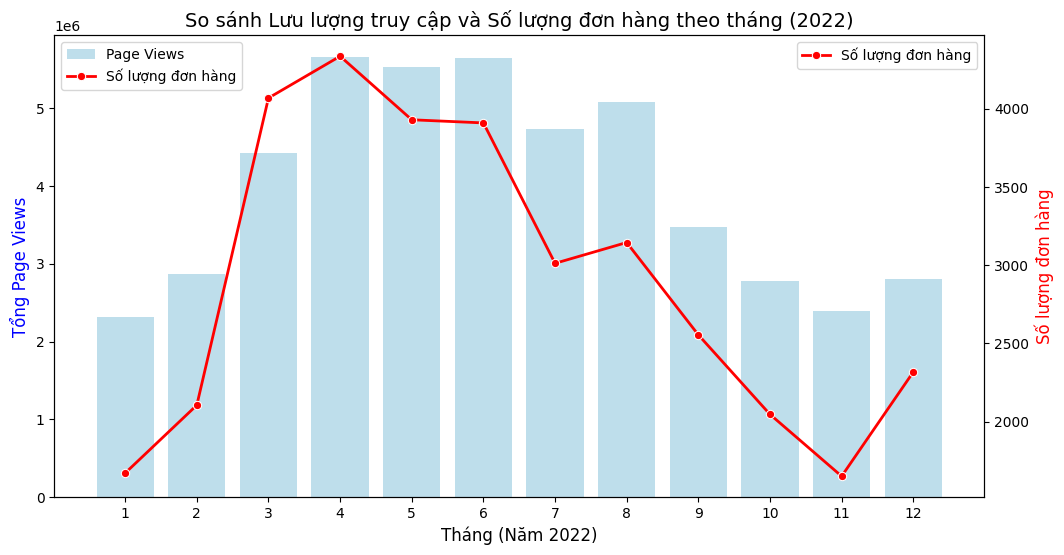

In [320]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Vẽ Page Views (Cột)
sb.barplot(x='month', y='page_views', data=analysis_2022, ax=ax1, alpha=0.6, color='skyblue', label='Page Views')
ax1.set_ylabel('Tổng Page Views', color='blue', fontsize=12)
ax1.set_xlabel('Tháng (Năm 2022)', fontsize=12)

# Tạo trục Y thứ hai cho Orders
ax2 = ax1.twinx()
sb.lineplot(x=range(len(analysis_2022)), y='order_count', data=analysis_2022, ax=ax2, color='red', marker='o', linewidth=2, label='Số lượng đơn hàng')
ax2.set_ylabel('Số lượng đơn hàng', color='red', fontsize=12)

# Gộp Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('So sánh Lưu lượng truy cập và Số lượng đơn hàng theo tháng (2022)', fontsize=14)
plt.show()

In [321]:
#Thay đổi định dạng cột date ở promotions
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])
#Hàm kiểm tra xem một ngày có nằm trong bất kỳ chương trình promo nào không
def check_promo(current_date):
    # Kiểm tra xem current_date có nằm giữa start_date và end_date của dòng nào trong bảng promotions không
    is_active = promotions[(current_date >= promotions['start_date']) & 
                           (current_date <= promotions['end_date'])]
    return 1 if not is_active.empty else 0

# 3. Áp dụng vào web_traffic
web_traffic['is_promo_day'] = web_traffic['date'].apply(check_promo)


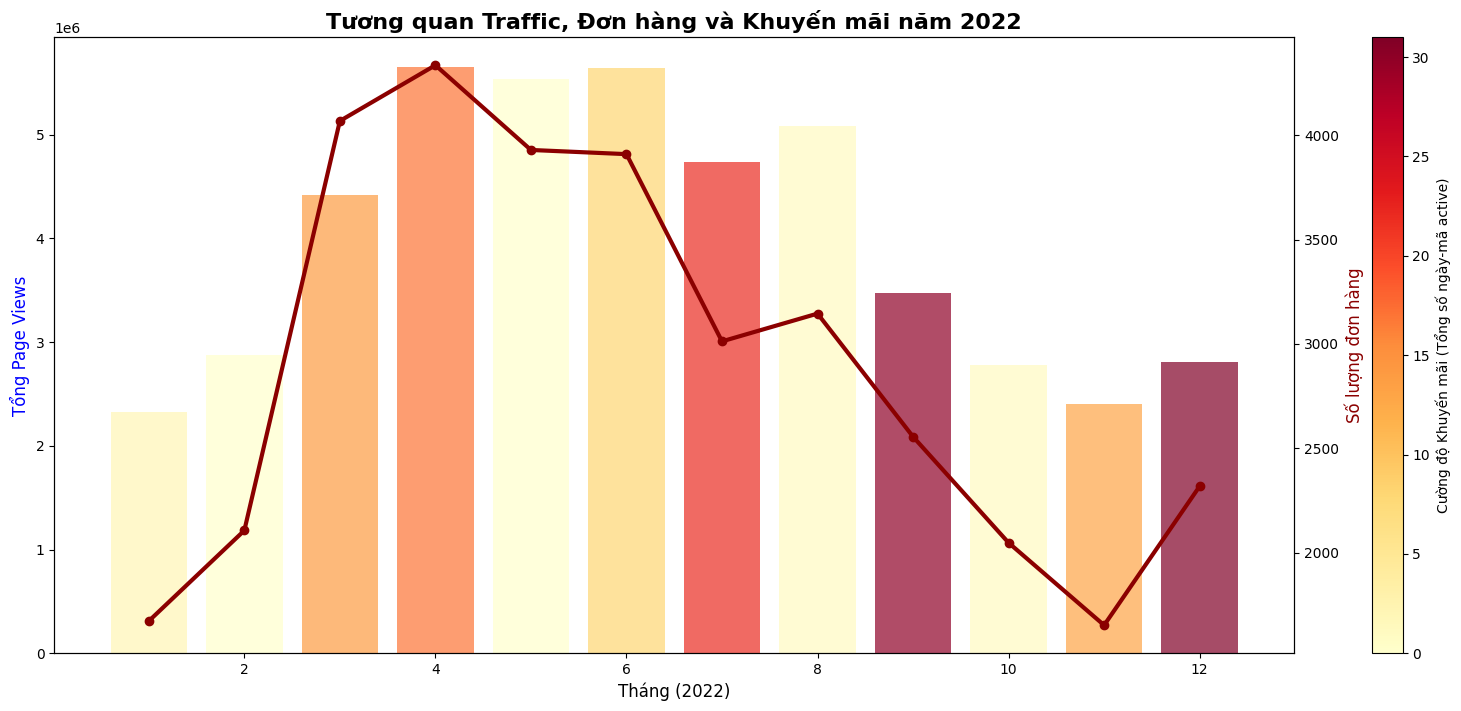

In [322]:
# 3. Tạo "Bản đồ Khuyến mãi" cho từng ngày trong năm 2022
all_dates_2022 = pd.date_range(start='2022-01-01', end='2022-12-31')
promo_map = pd.Series(0, index=all_dates_2022)

for _, row in promotions.iterrows():
    # Đánh dấu những ngày có khuyến mãi (cộng dồn nếu có nhiều mã chạy cùng lúc)
    mask = (all_dates_2022 >= row['start_date']) & (all_dates_2022 <= row['end_date'])
    promo_map[mask] += 1

# 4. Gom dữ liệu theo Tháng
promo_monthly = promo_map.resample('ME').sum().reset_index()
promo_monthly.columns = ['date', 'promo_intensity']
promo_monthly['month'] = promo_monthly['date'].dt.month

traffic_monthly = web_traffic_2022.groupby(web_traffic_2022['date'].dt.month)['page_views'].sum().reset_index()
orders_monthly = orders_2022.groupby(orders_2022['order_date'].dt.month)['order_id'].nunique().reset_index()

# Merge lại thành bảng tổng hợp
final_df = traffic_monthly.merge(orders_monthly, left_on='date', right_on='order_date')
final_df = final_df.merge(promo_monthly[['month', 'promo_intensity']], left_on='date', right_on='month')

# 5. Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(20, 8))

# Vẽ Page Views (Dùng màu sắc của cột để thể hiện cường độ khuyến mãi)
norm = plt.Normalize(final_df['promo_intensity'].min(), final_df['promo_intensity'].max())
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
colors = [sm.to_rgba(x) for x in final_df['promo_intensity']]

bars = ax1.bar(final_df['month'], final_df['page_views'], color=colors, alpha=0.7, label='Page Views')
ax1.set_xlabel('Tháng (2022)', fontsize=12)
ax1.set_ylabel('Tổng Page Views', color='blue', fontsize=12)

# Vẽ Orders (Đường line)
ax2 = ax1.twinx()
ax2.plot(final_df['month'], final_df['order_id'], color='darkred', marker='o', linewidth=3, label='Số lượng đơn hàng')
ax2.set_ylabel('Số lượng đơn hàng', color='darkred', fontsize=12)

# Thêm Colorbar để giải thích cường độ khuyến mãi
cbar = fig.colorbar(sm, ax=ax2)
cbar.set_label('Cường độ Khuyến mãi (Tổng số ngày-mã active)')

plt.title('Tương quan Traffic, Đơn hàng và Khuyến mãi năm 2022', fontsize=16, fontweight='bold')
plt.show()

In [323]:

# 2. Merge orders với shipments để lấy phí ship
# Lưu ý: Chỉ những đơn đã xuất kho mới có trong shipments
df_delivery = orders_2022.merge(shipments[['order_id', 'shipping_fee']], on='order_id', how='inner')

# 3. Phân loại phí ship thành các nhóm (bins)
bins = [-1, 0, 15, 30, 50, 100]
labels = ['Free', '0-15', '15-30', '30-50', '>50']
df_delivery['fee_range'] = pd.cut(df_delivery['shipping_fee'], bins=bins, labels=labels)

# 4. Tính Success Rate theo từng nhóm phí ship
success_analysis = df_delivery.groupby('fee_range').agg(
    total_shipped=('order_id', 'count'),
    total_delivered=('order_status', lambda x: (x == 'delivered').sum())
).reset_index()

success_analysis['success_rate'] = (success_analysis['total_delivered'] / success_analysis['total_shipped']) * 100

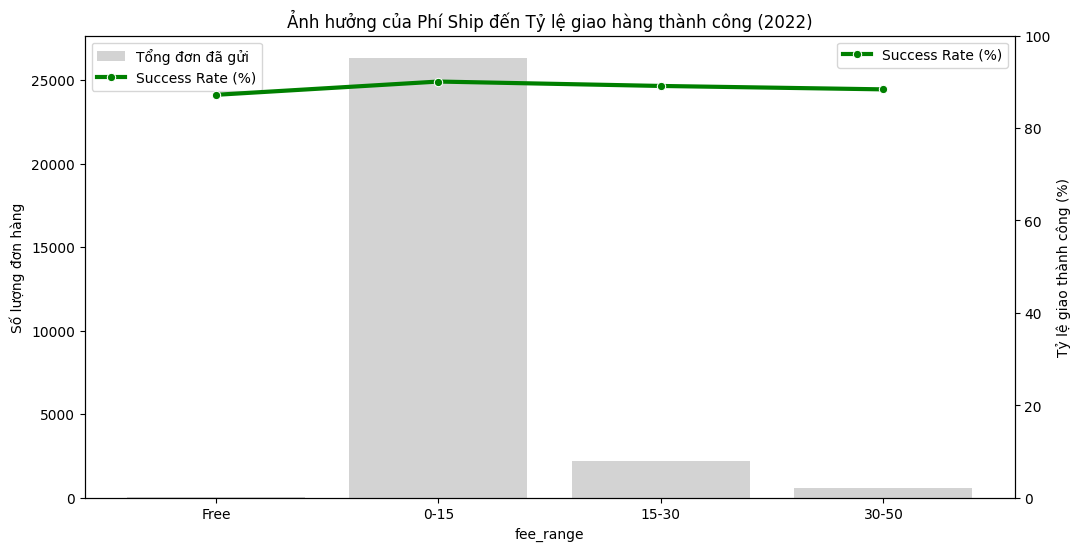

In [324]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Vẽ cột: Tổng số đơn hàng đã gửi (Total Shipped)
sb.barplot(x='fee_range', y='total_shipped', data=success_analysis, ax=ax1, color='lightgray', label='Tổng đơn đã gửi')
ax1.set_ylabel('Số lượng đơn hàng')

# Vẽ đường: Success Rate
ax2 = ax1.twinx()
sb.lineplot(x='fee_range', y='success_rate', data=success_analysis, ax=ax2, color='green', marker='o', linewidth=3, label='Success Rate (%)')
ax2.set_ylabel('Tỷ lệ giao thành công (%)')
ax2.set_ylim(0, 100) # Đặt giới hạn 100% để dễ quan sát

# Gộp Legend
lines, labels_1 = ax1.get_legend_handles_labels()
lines2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_1 + labels_2, loc='upper left')

plt.title('Ảnh hưởng của Phí Ship đến Tỷ lệ giao hàng thành công (2022)')
plt.show()

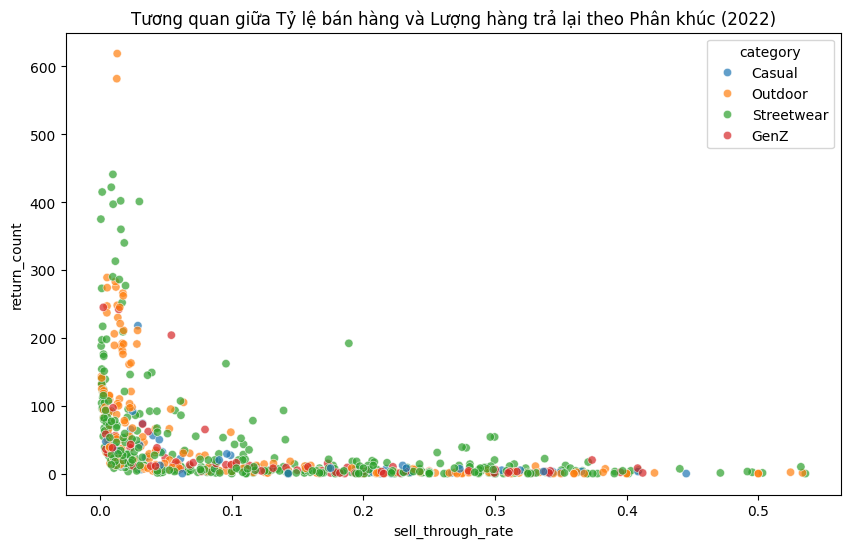

In [325]:
# 1. Tính toán từ bảng Inventory (lấy trung bình theo năm 2022)
inventory_2022 = inventory[inventory['year'] == 2022]
prod_inventory = inventory_2022.groupby('product_id').agg({
    'sell_through_rate': 'mean',
    'units_sold': 'sum',
    'reorder_flag': 'sum',
    'category': 'first'
}).reset_index()

# 2. Tính số lượng trả hàng từ bảng Returns
prod_returns = returns.groupby('product_id')['return_id'].count().reset_index()
prod_returns.columns = ['product_id', 'return_count']

# 3. Merge dữ liệu
df_final = prod_inventory.merge(prod_returns, on='product_id', how='left').fillna(0)

# 4. Vẽ biểu đồ phân tán (Sell-through vs Returns)

plt.figure(figsize=(10, 6))
sb.scatterplot(data=df_final, x='sell_through_rate', y='return_count', hue='category', alpha=0.7)
plt.title('Tương quan giữa Tỷ lệ bán hàng và Lượng hàng trả lại theo Phân khúc (2022)')
plt.show()

4. Machine learning 


In [371]:
#Import thư viện 
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedKFold, train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score,root_mean_squared_error
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [372]:
sales.head()

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [373]:
#1. Load data
sales = pd.read_csv("sales.csv", parse_dates=["Date"])
#Giữ nguyên data gốc
sales_copy = sales.copy()
#Sort + set_index
sales_copy = sales.sort_values('Date')
sales_copy = sales.set_index('Date')

Baseline

In [387]:
#Feature engineering 
sales_copy['lag_1']=sales_copy['Revenue'].shift(1)
sales_copy['lag_7']=sales_copy['Revenue'].shift(7)
sales_copy['rolling_mean_7']=sales_copy['Revenue'].rolling(7).mean()
sales_copy['day_of_week']= sales_copy.index.day_of_week
sales_copy['month']=sales_copy.index.month
#Drop NA
sales_model=sales_copy.dropna()
X= sales_model.drop(columns=['Revenue'], errors='ignore')
y= sales_model['Revenue']
#Time-based split
train_size = int(len(sales_model) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]


Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
MAE: 235923.56058396815
R2: 0.9425702742075142


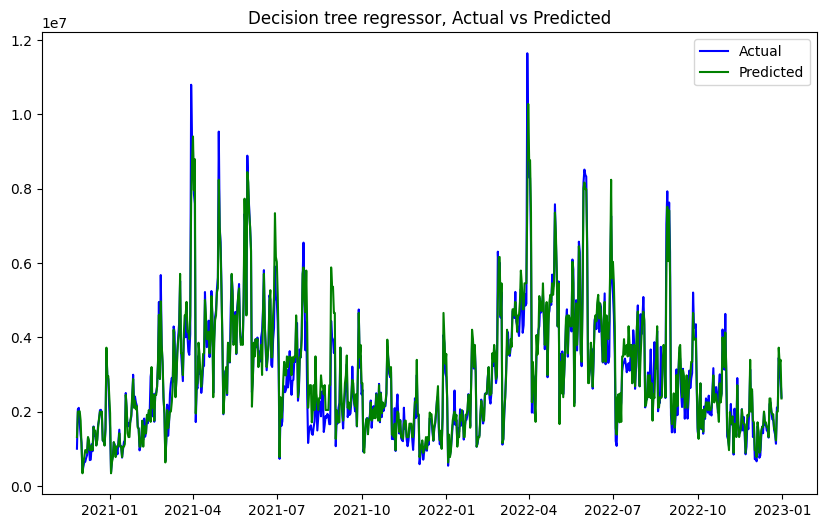

In [388]:
#DecisionTreeRegressor
dtr_model = DecisionTreeRegressor(random_state=42)
#Tuning
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    dtr_model,
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best params:", grid.best_params_)
 #Predict
y_pred = best_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
r2=r2_score(y_test, y_pred)
print("R2:",r2)
# Lập bảng
plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test, label="Actual", color="blue")

plt.plot(y_test.index, y_pred, color="green", label="Predicted")
plt.title(
    "Decision tree regressor, Actual vs Predicted" 
)
plt.legend()
plt.show()

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
MAE: 179263.95929830286
R2: 0.9713919893682108


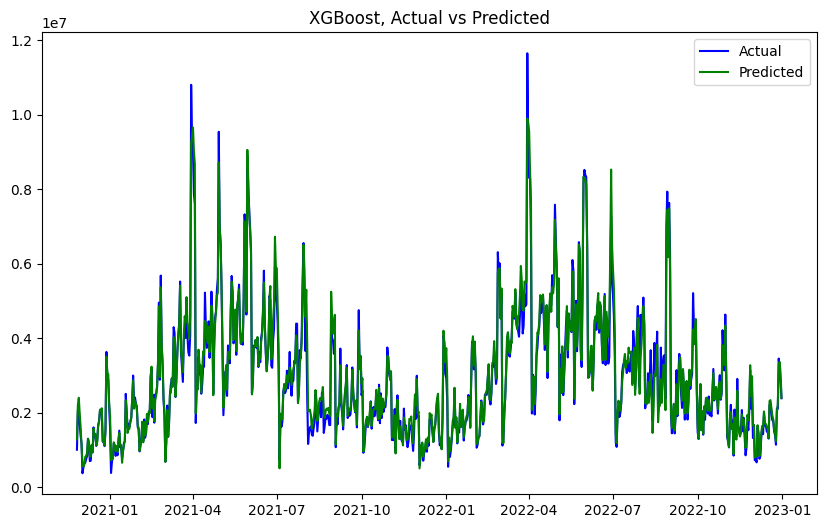

In [389]:
#XGBoost
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_xgb_model = grid.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)
print("Best params:", grid.best_params_)


# Evaluate
mae = mean_absolute_error(y_test, y_pred_xgb)
print("MAE:", mae)
r2=r2_score(y_test, y_pred_xgb)
print("R2:",r2)
#Lập biểu đồ
plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test, label="Actual", color="blue")
plt.plot(y_test.index, y_pred_xgb, color="green", label="Predicted")
plt.title(
    "XGBoost, Actual vs Predicted" 
)
plt.legend()
plt.show()


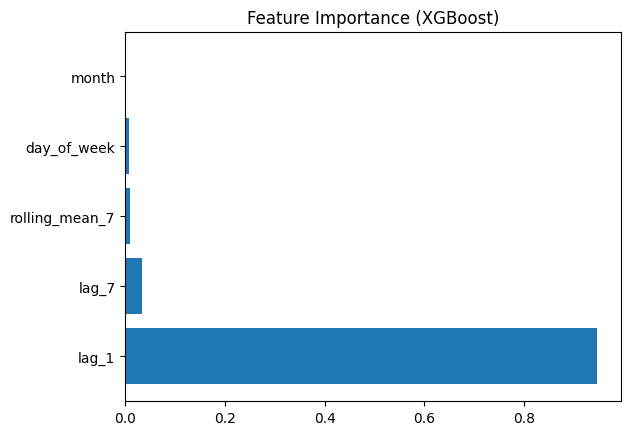

In [377]:
importances = best_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance (XGBoost)")
plt.show()

Feature Engineering

MAE: 179813.60627610967
R2 Score: 0.9688292286308119


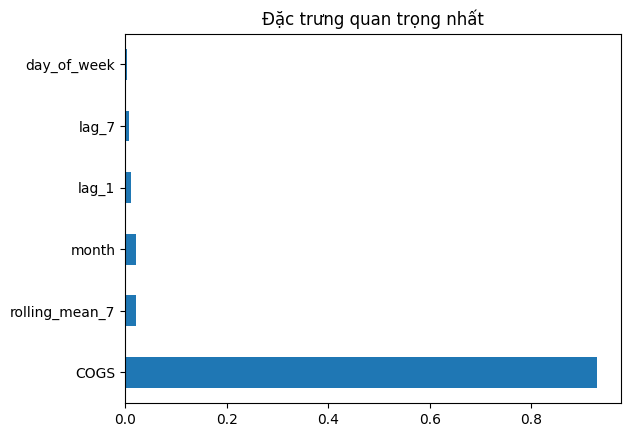

In [402]:
#Xử lý dữ liệu thiếu
sales_model1= sales_copy.dropna()
#Đặt các biến X,y
X_new = sales_model1.drop(columns=['Revenue'], errors='ignore')
y_new = sales_model1['Revenue']
#Xác định các biến cần train
train_size = int(len(sales_model) * 0.8)
X_train_new, X_test_new = X_new.iloc[:train_size], X.iloc[train_size:]
y_train_new, y_test_new = y_new.iloc[:train_size], y.iloc[train_size:]

# 5. XÂY DỰNG PIPELINE
# Sử dụng tham số XGBoost bạn đã Grid Search được từ Baseline
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    tree_method='hist'
)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Đề phòng giá trị lạ
    ('model', xgb_model)
])

# Huấn luyện mô hình
pipeline.fit(X_train, y_train)

# 6. ĐÁNH GIÁ (Evaluation Metrics)
y_pred_test_new = pipeline.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test_new, y_pred_test_new)}")
print(f"R2 Score: {r2_score(y_test_new, y_pred_test_new)}")

# 7. TRỰC QUAN HÓA ĐỘ QUAN TRỌNG (Feature Importance)
import matplotlib.pyplot as plt
feat_importances = pd.Series(pipeline.named_steps['model'].feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Đặc trưng quan trọng nhất')
plt.show()

In [404]:
#Xác định các cột trong X_train_new
print("Các cột hiện có trong X_train_new:", X_train_new.columns.tolist())

Các cột hiện có trong X_train_new: ['COGS', 'lag_1', 'lag_7', 'rolling_mean_7', 'day_of_week', 'month']


In [ ]:
# Xác định danh sách cột theo loại
categorical_features = ['day_of_week', 'month']
numerical_features = [col for col in X_train.columns if col not in categorical_features]

# 1. Định nghĩa các bước tiền xử lý cho từng loại dữ liệu
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 2. Kết hợp các bộ xử lý lại bằng ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 3. Tạo Pipeline tổng hoàn chỉnh
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

# Huấn luyện
pipeline.fit(X_train_new, y_train_new)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [405]:
print("Các cột hiện có trong X_test_new:", X_test_new.columns.tolist())

Các cột hiện có trong X_test_new: ['COGS', 'lag_1', 'lag_7', 'rolling_mean_7', 'day_of_week', 'month']


MAE: 180537.5382000653
R2: 0.968974567015833


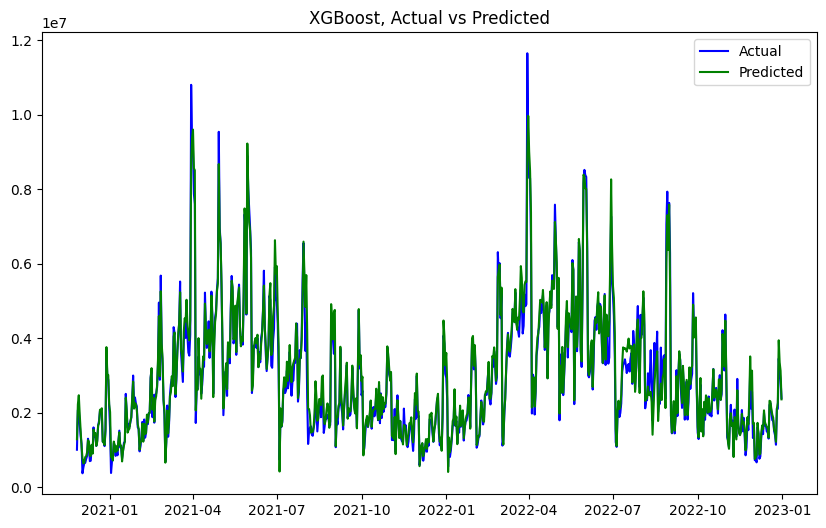

In [407]:
#Dự báo
y_pred_test_new = pipeline.predict(X_test_new)
# Evaluate
mae = mean_absolute_error(y_test_new, y_pred_test_new)
print("MAE:", mae)
r2=r2_score(y_test_new, y_pred_test_new)
print("R2:",r2)
plt.figure(figsize=(10,6))
plt.plot(y_test_new.index, y_test, label="Actual", color="blue")
plt.plot(y_test_new.index, y_pred_test_new, color="green", label="Predicted")
plt.title(
    "XGBoost, Actual vs Predicted" 
)
plt.legend()
plt.show()

=> So sánh cả 3 trường hợp thì sử dụng XGBoost dạng baseline sẽ có hiệu quả cao hơn so với sử dụng onehotencoder()

Cross-validation

In [398]:
# HUẤN LUYỆN MODEL REVENUE 

best_revenue_model = grid.best_estimator_ 

#  HUẤN LUYỆN MODEL COGS
# Tạo X, y mới cho COGS
y_cogs = sales_model['COGS']
# Huấn luyện lại model mới (có thể dùng lại param_grid cũ)
# Split dữ liệu COGS dựa trên train_size của XGBoost Baseline
y_train_cogs = y_cogs.iloc[:train_size]
y_test_cogs = y_cogs.iloc[train_size:]
grid_cogs = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
grid_cogs.fit(X_train, y_train_cogs) 
best_cogs_model = grid_cogs.best_estimator_

In [ ]:
def run_final_forecast_v3(model_rev, model_cogs, sales_df, periods=548):
    # Lấy danh sách tên cột mà từng model yêu cầu (Cực kỳ quan trọng)
    cols_rev = model_rev.get_booster().feature_names
    cols_cogs = model_cogs.get_booster().feature_names
    
    last_known_row = sales_df.iloc[-1]
    history_rev = sales_df['Revenue'].iloc[-7:].tolist()
    history_cogs = sales_df['COGS'].iloc[-7:].tolist()
    
    predictions_rev = []
    predictions_cogs = []
    
    # Khởi tạo dòng hiện tại
    current_row = last_known_row.copy()
    forecast_dates = pd.date_range(start=last_known_row.name + pd.Timedelta(days=1), 
                                   periods=periods, freq='D')

    for date in forecast_dates:
        # --- BƯỚC 1: DỰ BÁO COGS ---
        # Ép X_input_cogs phải có ĐÚNG và ĐỦ các cột mà model_cogs cần
        X_input_cogs = pd.DataFrame([current_row])[cols_cogs]
        pred_cogs = model_cogs.predict(X_input_cogs)[0]
        
        # --- BƯỚC 2: DỰ BÁO REVENUE ---
        # Cập nhật giá trị COGS vừa dự báo được vào row hiện tại
        current_row['COGS'] = pred_cogs
        
        # Ép X_input_rev phải có ĐÚNG và ĐỦ các cột mà model_rev cần
        X_input_rev = pd.DataFrame([current_row])[cols_rev]
        pred_rev = model_rev.predict(X_input_rev)[0]
        
        # Lưu kết quả
        predictions_rev.append(pred_rev)
        predictions_cogs.append(pred_cogs)
        
        # --- BƯỚC 3: CẬP NHẬT CHO NGÀY TIẾP THEO ---
        history_rev.append(pred_rev)
        history_cogs.append(pred_cogs)
        
        current_row['lag_1'] = pred_rev
        current_row['lag_7'] = history_rev[-7]
        current_row['rolling_mean_7'] = np.mean(history_rev[-7:])
        current_row['day_of_week'] = date.dayofweek
        current_row['month'] = date.month
        current_row.name = date
        
    return predictions_rev, predictions_cogs

# Thực hiện dự báo 
rev_pred, cogs_pred = run_final_forecast_v3(best_revenue_model, best_cogs_model, sales_model, periods=548)

In [410]:
# --- XUẤT FILE CSV ---
forecast_dates = pd.date_range(start=sales_model.index[-1] + pd.Timedelta(days=1), periods=548, freq='D')

submission = pd.DataFrame({
    'Date': forecast_dates,
    'Revenue': rev_pred,
    'COGS': cogs_pred
})

# Đảm bảo không có giá trị âm và làm tròn 2 chữ số
submission[['Revenue', 'COGS']] = submission[['Revenue', 'COGS']].clip(lower=0).round(2)

# Lưu file
submission.to_csv('submission_GoldenNerd_Datathon2026.csv', index=False, lineterminator='\n')
print("--- HOÀN TẤT ---")
print(f"Đã lưu file: submission_GoldenNerd_Datathon2026.csv")
print(submission.head())

--- HOÀN TẤT ---
Đã lưu file: submission_GoldenNerd_Datathon2026.csv
        Date     Revenue        COGS
0 2023-01-01  2393803.75  2285479.50
1 2023-01-02  2933676.25  2285567.75
2 2023-01-03  2932371.75  2285608.25
3 2023-01-04  2928134.00  2285608.25
4 2023-01-05  2927820.25  2285608.25
